# Risk Metrics

This notebook computes the distributional **risk / vulnerability metrics** derived from the
conditional (Growth-at-Risk) and unconditional (historical) Johnson SU fits. The metric
implementations live in `auxi.vulnerability_metrics`; this notebook is the orchestration /
presentation layer. The distribution *fitting and goodness-of-fit* work stays in
`distribution_analysis_jsu.ipynb`.

Metrics covered:
1. Relative entropy vs a **Normal** baseline (expanding window)
2. Relative entropy vs a **Normal** baseline (rolling window)
3. Relative entropy vs the **unconditional** distribution - Adrian et al. (expanding window)
4. Relative entropy vs the **unconditional** distribution - Adrian et al. (rolling window)
5. Brent price vs full-distribution entropy (overlay)
6. Distributional **skewness** over time (expanding window)

## Setup

In [1]:
import pandas as pd
import numpy as np
import os

os.chdir("C:/Users/Alejandro/Documents/MQuEA/TFM/main_code")

import auxi.vulnerability_metrics as vm
from auxi.data import import_data
from pathlib import Path

In [2]:
data = import_data(freq="Daily")
price_series = data['Brent_Price']

c:\Users\Alejandro\Documents\MQuEA\TFM\main_code\auxi\data.py:353: DtypeWarning: Columns (40,41,42) have mixed types. Specify dtype option on import or set low_memory=False.
  panel = pd.read_csv(csv_path, index_col=0, parse_dates=True)


In [3]:
import json as _json, datetime

# ── Model Settings ─────────────────────────────────────────────────────
# Change any parameter here — OOS_DIR is derived automatically.
horizon      = 5
quantiles    = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
tau          = 0.95
window       =   1_008       # rolling window size (blocks 2 & 4)
x_var        = "GPRD_MA7"
y_var        = "Brent_Return"
retrain_after = 30
control_vars = [
    "usd_index_ld",
    "Realized_Volatility",
    "badi_ld"
]
VAR_CONFIDENCE  = 0.975
VAR_HORIZON     = horizon
VAR_WINDOW      = 1_008    # 4 trading years × 252
CVAR_CONFIDENCE = 0.975
CVAR_HORIZON    = horizon
CVAR_WINDOW     = 1_008

# ── Derive results folder from settings ──────────────────────────────
_x_slug = x_var.lower()
OOS_DIR = Path(f"../results/oos/h{horizon}_{_x_slug}")
OOS_DIR.mkdir(parents=True, exist_ok=True)

_cfg_file = OOS_DIR / "config.json"
if not _cfg_file.exists():
    _cfg = {
        "description": f"OoS — h={horizon}, {x_var} specification",
        "horizon": horizon, "x_var": x_var, "y_var": y_var,
        "controls": control_vars, "quantiles": quantiles,
        "tau": tau, "rolling_window": window, "retrain_after": retrain_after,
        "sample_start": "1990-01-01",
        "created": datetime.date.today().strftime("%Y-%m-%d"),
    }
    with open(_cfg_file, "w") as _f:
        _json.dump(_cfg, _f, indent=2)
    print(f"New config created → {OOS_DIR.name}/")
else:
    with open(_cfg_file) as _f:
        _cfg = _json.load(_f)
    print(f"Existing config loaded → {OOS_DIR.name}/")

print(f"  h={horizon}, tau={tau}, window={window}, retrain_after={retrain_after}, x={x_var}, y={y_var}")

Existing config loaded → h5_gprd_ma7/
  h=5, tau=0.95, window=1008, retrain_after=30, x=GPRD_MA7, y=Brent_Return


## 1. Relative Entropy vs Normal Baseline - Expanding Window

Following the Growth-at-Risk literature, we measure how far the **conditional** (GaR) predictive
density departs from a reference distribution via the Kullback-Leibler relative entropy, decomposed
into **Full**, **Left-tail (downside)** and **Right-tail (upside)** components. Here the reference
`Q(x)` is a **Normal** baseline calibrated to the historical mean and standard deviation, and the
estimation window is **expanding** (all history up to each date). The `tau` mark sets where the
left/right tail split falls (0.95 -> 5th / 95th percentiles).

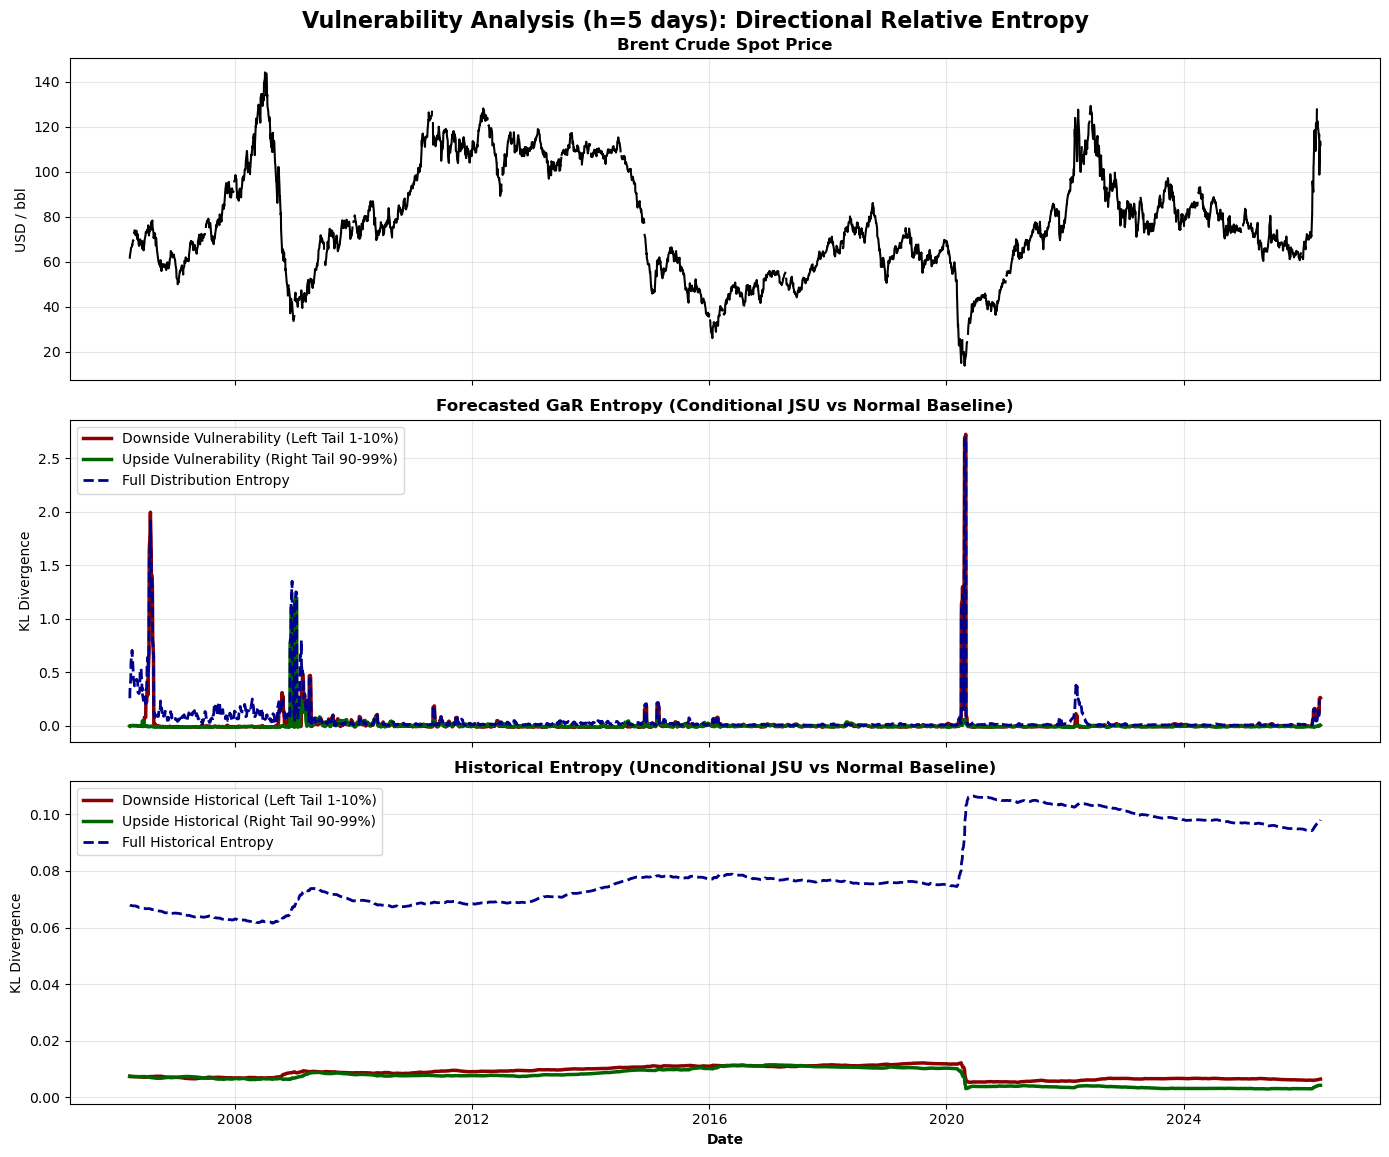

In [4]:
_p = OOS_DIR / "entropy_exp.parquet"
if _p.exists():
    df_entropy_results = pd.read_parquet(_p)
else:
    df_entropy_results = vm.generate_oos_entropy_normal(
        df       = data,
        x_var    = x_var,
        y_var    = y_var,
        controls = control_vars,
        quantiles= quantiles,
        h        = horizon,
        tau      = tau,
        retrain_after = retrain_after
    )
    df_entropy_results.to_parquet(_p)

vm.plot_tail_entropy(price_series=price_series, df_entropy=df_entropy_results, h=horizon)

## 2. Relative Entropy vs Normal Baseline - Rolling Window

The same metric as Block 1, but both the conditional fit and the historical baseline use only the
most recent `window` observations. Contrasting the rolling and expanding signals shows how much the
vulnerability estimate depends on distant history.

In [5]:
_p = OOS_DIR / "entropy_roll.parquet"
if _p.exists():
    df_entropy_results_rolling = pd.read_parquet(_p)
else:
    df_entropy_results_rolling = vm.generate_oos_entropy_normal_rolling(
        df       = data,
        x_var    = x_var,
        y_var    = y_var,
        controls = control_vars,
        quantiles= quantiles,
        h        = horizon,
        window   = window,
        tau      = tau,
        retrain_after = retrain_after
    )
    df_entropy_results_rolling.to_parquet(_p)

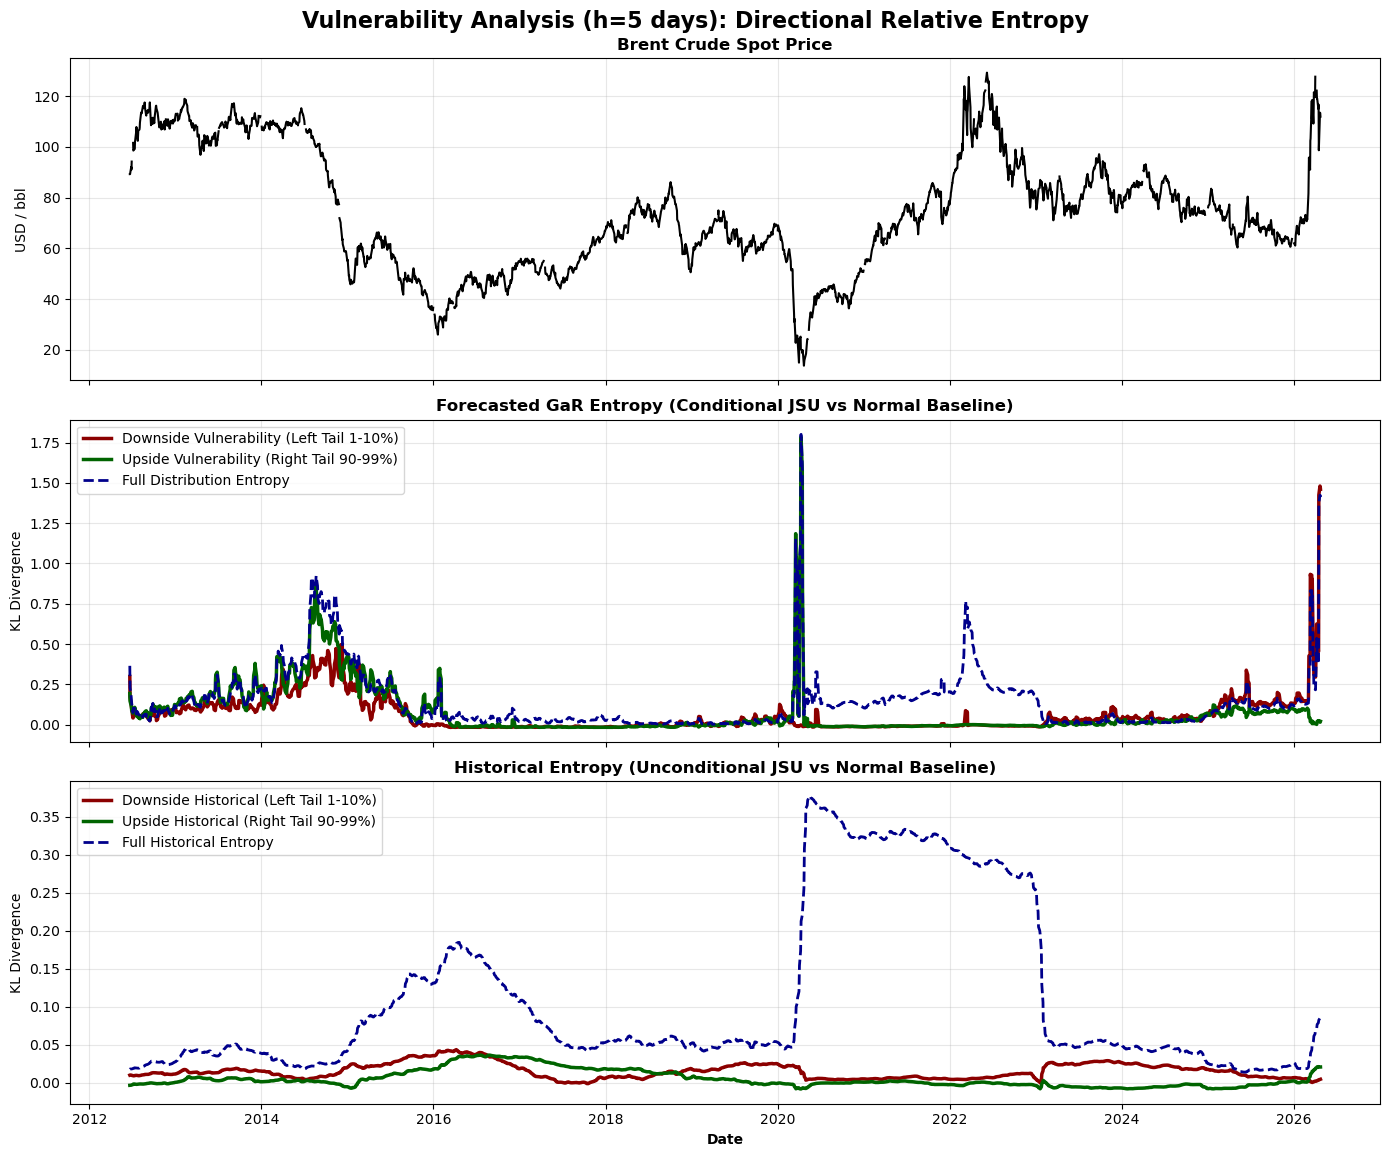

In [6]:
vm.plot_tail_entropy(price_series=price_series, df_entropy=df_entropy_results_rolling, h=horizon)

## Stressed Analysis

Brent price (left axis) vs Full KL divergence against Normal (right axis) from the
rolling-window entropy (Block 2, h=5), zoomed into each structural-shock episode.
One subplot per stressed period, arranged in a 2-column grid.

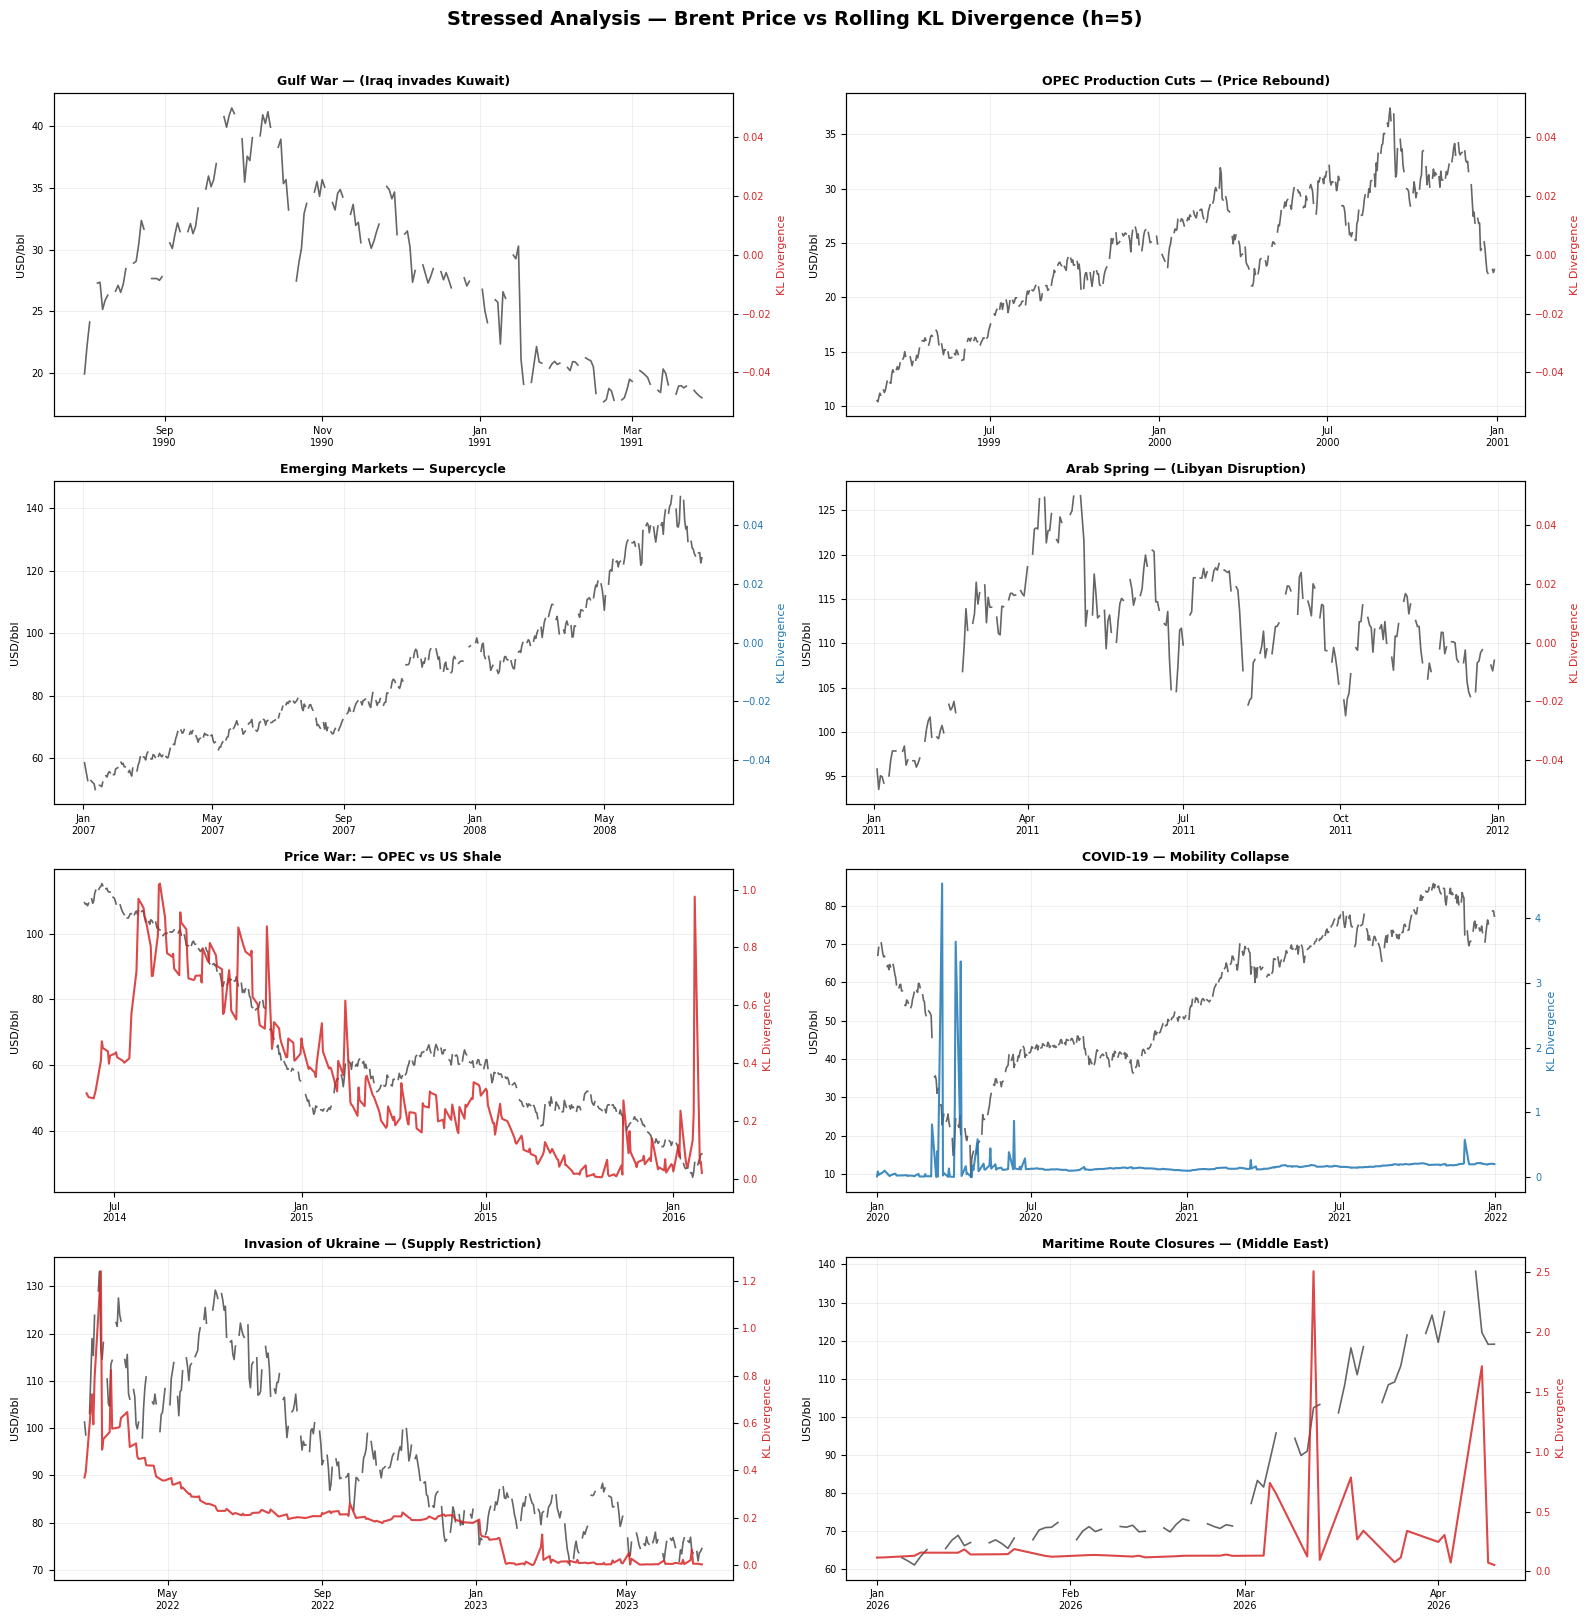

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

structural_shocks = [
    ('1990-08-01', '1991-03-31', 'Supply', 'max', 'Gulf War\n(Iraq invades Kuwait)'),
    ('1999-03-01', '2000-12-31', 'Supply', 'max', 'OPEC Production Cuts\n(Price Rebound)'),
    ('2007-01-01', '2008-07-31', 'Demand', 'max', 'Emerging Markets\nSupercycle'),
    ('2011-01-01', '2011-12-31', 'Supply', 'max', 'Arab Spring\n(Libyan Disruption)'),
    ('2014-06-01', '2016-01-31', 'Supply', 'min', 'Price War:\nOPEC vs US Shale'),
    ('2020-01-01', '2021-12-31', 'Demand', 'min', 'COVID-19\nMobility Collapse'),
    ('2022-02-24', '2023-06-30', 'Supply', 'max', 'Invasion of Ukraine\n(Supply Restriction)'),
    ('2026-01-01', '2026-04-12', 'Supply', 'max', 'Maritime Route Closures\n(Middle East)'),
]

n_shocks = len(structural_shocks)
ncols = 2
nrows = (n_shocks + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

supply_color = '#d62728'
demand_color = '#1f77b4'

for i, (start, end, shock_type, _, label) in enumerate(structural_shocks):
    ax_price = axes[i]
    mask = (price_series.index >= start) & (price_series.index <= end)
    ps = price_series.loc[mask]

    mask_ent = (df_entropy_results_rolling.index >= start) & (df_entropy_results_rolling.index <= end)
    ent = df_entropy_results_rolling.loc[mask_ent, 'Full_Entropy']

    color = supply_color if shock_type == 'Supply' else demand_color

    ax_price.plot(ps.index, ps.values, color='black', linewidth=1.2, alpha=0.6)
    ax_price.set_ylabel('USD/bbl', fontsize=8)
    ax_price.tick_params(axis='both', labelsize=7)
    ax_price.grid(True, alpha=0.2)

    ax_ent = ax_price.twinx()
    ax_ent.plot(ent.index, ent.values, color=color, linewidth=1.5, alpha=0.85)
    ax_ent.set_ylabel('KL Divergence', fontsize=8, color=color)
    ax_ent.tick_params(axis='y', labelcolor=color, labelsize=7)

    ax_price.set_title(label.replace('\n', ' — '), fontsize=9, fontweight='bold')
    ax_price.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax_price.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=3, maxticks=6))

# hide unused axes
for j in range(n_shocks, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    f'Stressed Analysis — Brent Price vs Rolling KL Divergence (h={horizon})',
    fontsize=14, fontweight='bold', y=1.01,
)
fig.tight_layout()
plt.show()

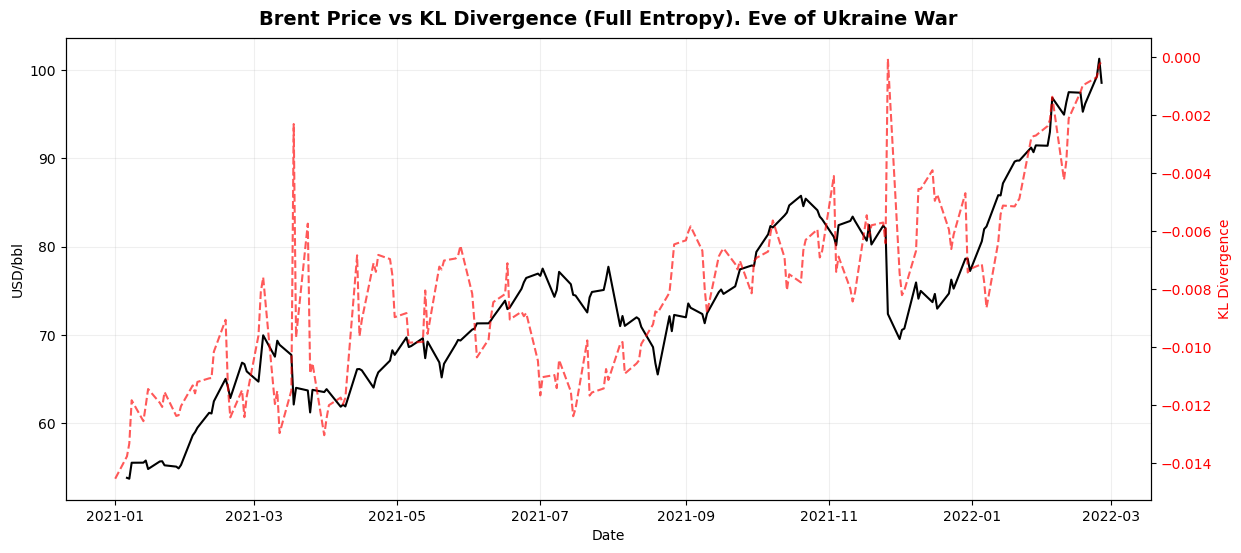

In [71]:


import seaborn as sns
import matplotlib.pyplot as plt

# --- Merge the time series ---
brent = data[["Brent_Price"]]
to_plot = brent.merge(df_entropy_results_rolling[['Right_Entropy']], left_index=True, right_index=True, how='inner')
# to_plot.dropna(inplace = True)

# --- Create the desired subsample ---
to_plot = to_plot.loc['2021-01-01':'2022-03-01']



fig, ax = plt.subplots(figsize=(14, 6))

plt.title(f'Brent Price vs KL Divergence (Full Entropy). Eve of Ukraine War', fontsize=14, fontweight='bold', y=1.01)
# Plot Brent price on the left axis
sns.lineplot(data=to_plot, x=to_plot.index, y='Brent_Price', color='black',linewidth=1.5, ax=ax)
ax.set_ylabel('USD/bbl')
ax.grid(True, alpha=0.2)
# Plot KL divergence on a secondary y-axis
ax2 = ax.twinx()
sns.lineplot(data=to_plot, x=to_plot.index, y='Right_Entropy', color='red', linewidth=1.5, ax=ax2, alpha=0.65, linestyle="--")
ax2.set_ylabel('KL Divergence', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.show()

## 3. Relative Entropy vs the Unconditional Distribution (Adrian et al.) - Expanding Window

In the seminal *Vulnerable Growth* framework (Adrian, Boyarchenko & Giannone), relative entropy is
measured against the **unconditional** distribution rather than a Normal reference. Here the baseline
`Q(x)` is the **unconditional JSU** fitted by MLE to the historical returns, and the tail mark is
taken from that unconditional JSU. These `*_vs_Uncond` columns are produced by the *same* expanding
run as Block 1, so we reuse `df_entropy_results` and just plot the new metric.

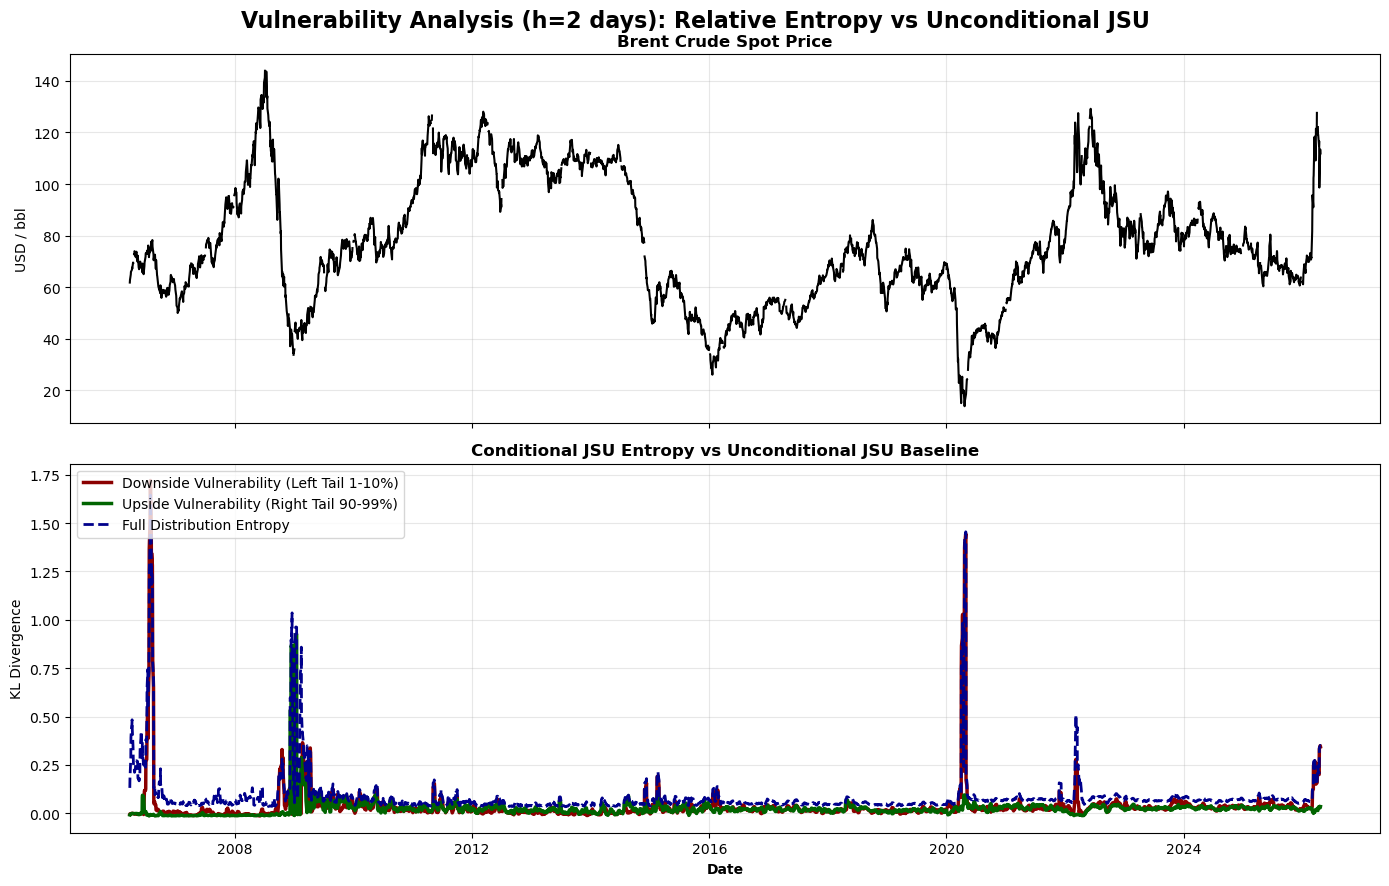

In [9]:
# The conditional-vs-unconditional entropy is already inside df_entropy_results
# (the *_vs_Uncond columns from the Block 1 expanding-window run, h=10).
vm.plot_tail_entropy_uncond(price_series=price_series, df_entropy=df_entropy_results, h=2)

## 4. Relative Entropy vs the Unconditional Distribution (Adrian et al.) - Rolling Window

The same Adrian et al. metric applied to the rolling-window run from Block 2.

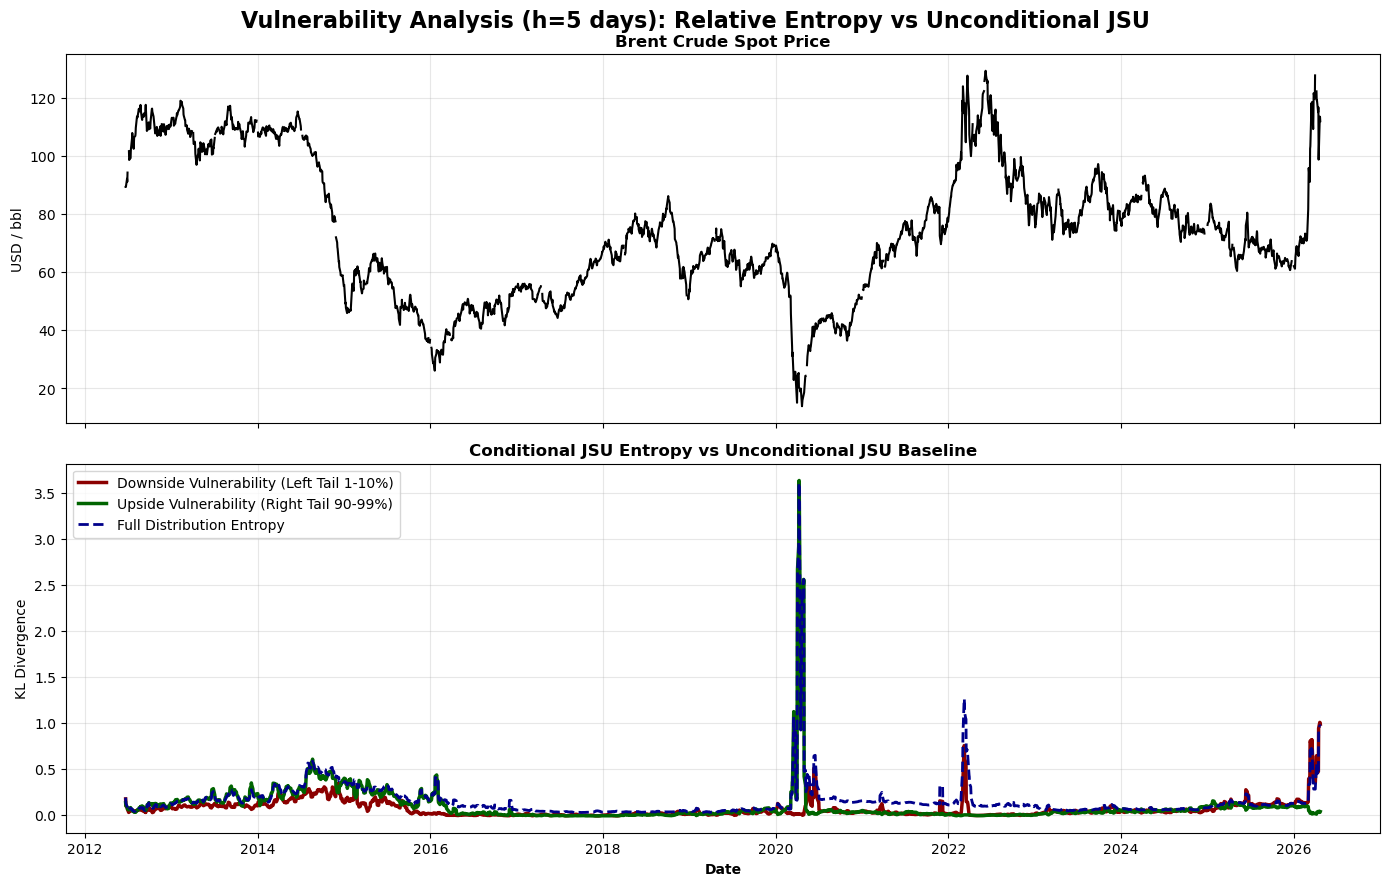

In [10]:
# Reuses the rolling-window run from Block 2 (h=10).
vm.plot_tail_entropy_uncond(price_series=price_series, df_entropy=df_entropy_results_rolling, h=horizon)

## 5. Brent Price vs Full-Distribution Entropy (Expanding)

A compact twin-axis overlay of the Brent price against the full-distribution entropy (vs the Normal
baseline) from the expanding-window run, to read co-movement between price level and distributional
vulnerability at a glance.

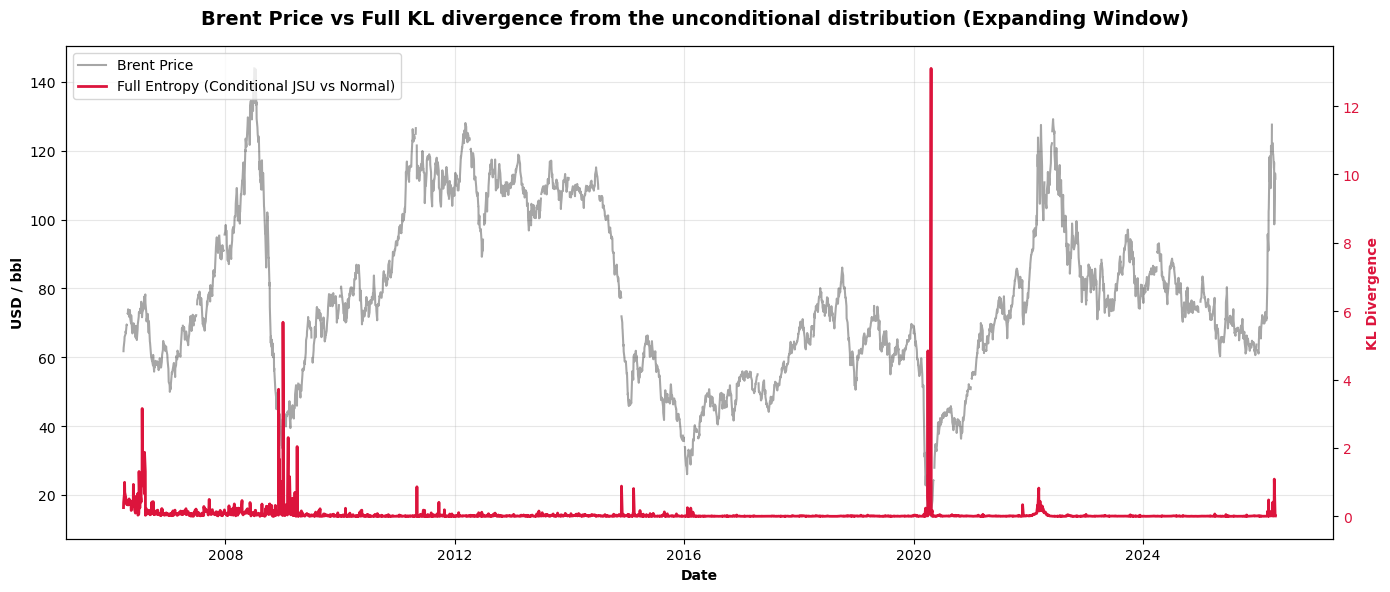

In [11]:
import matplotlib.pyplot as plt

fig, ax_price = plt.subplots(figsize=(14, 6))

# Left axis: Brent price (background)
aligned_price = price_series.reindex(df_entropy_results.index)
ax_price.plot(aligned_price.index, aligned_price.values,
              color='black', linewidth=1.5, alpha=0.35, label='Brent Price')
ax_price.set_xlabel("Date", fontweight='bold')
ax_price.set_ylabel("USD / bbl", fontweight='bold')
ax_price.grid(True, alpha=0.3)

# Right axis: full-distribution entropy (foreground)
ax_entropy = ax_price.twinx()
ax_entropy.plot(df_entropy_results.index, df_entropy_results['Full_Entropy'],
                color='crimson', linewidth=2.0, label='Full Entropy (Conditional JSU vs Normal)')
ax_entropy.set_ylabel("KL Divergence", fontweight='bold', color='crimson')
ax_entropy.tick_params(axis='y', labelcolor='crimson')

# Combined legend
lines_1, labels_1 = ax_price.get_legend_handles_labels()
lines_2, labels_2 = ax_entropy.get_legend_handles_labels()
ax_price.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

fig.suptitle("Brent Price vs Full KL divergence from the unconditional distribution (Expanding Window)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Distributional Skewness Over Time - Expanding Window

Beyond entropy, the **skewness** (Fisher's gamma_1) of the fitted JSU summarises directional
asymmetry: negative => fat left tail (downside risk), positive => fat right tail (upside). We track
both the conditional (GaR forecast) and the unconditional (historical) skewness over time.

In [12]:
_p = OOS_DIR / "skewness.parquet"
if _p.exists():
    df_skewness_results = pd.read_parquet(_p)
else:
    
    df_skewness_results = vm.generate_oos_skewness(
        df       = data,
        x_var    = x_var,
        y_var    = y_var,
        controls = control_vars,
        quantiles= quantiles,
        h        = horizon
    )
    df_skewness_results.to_parquet(_p)

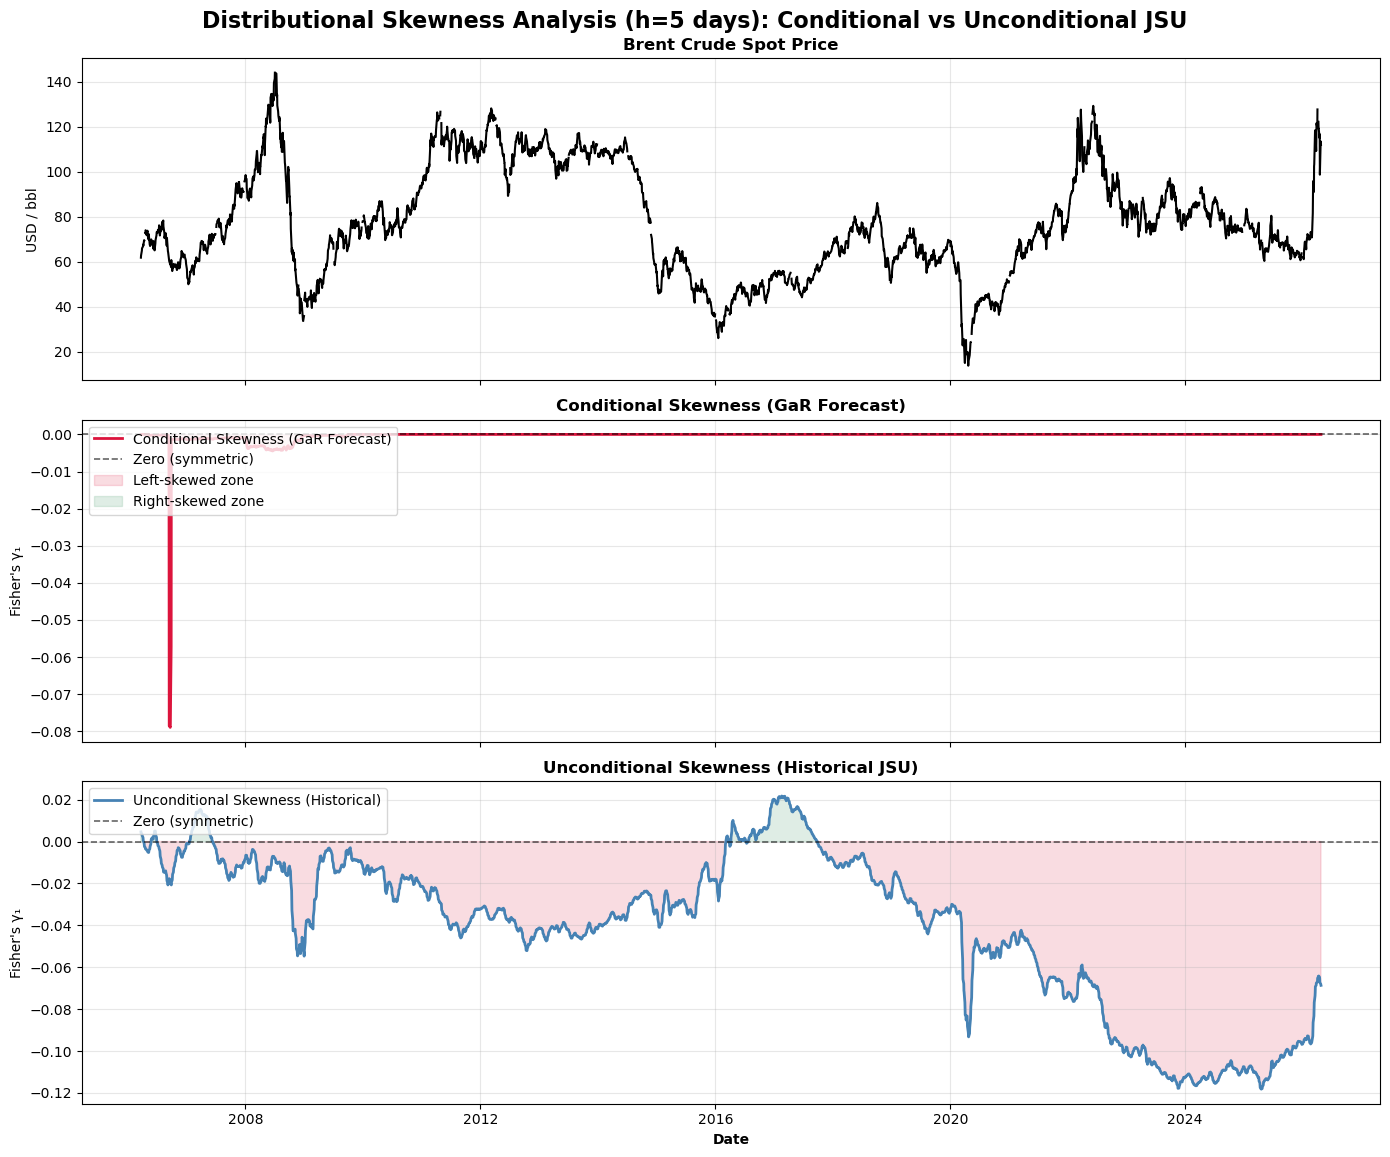

In [13]:
df_skewness_results_trimmed = df_skewness_results.loc["01-01-2012":]
vm.plot_skewness(price_series=price_series, df_skewness=df_skewness_results, h=horizon)

In [14]:
df_skewness_results

,Cond_Skewness,Uncond_Skewness,cond_a,cond_b,cond_loc,cond_scale
Date,,,,,,
2006-03-23,1.526755e-05,0.004618,-3.222900e+00,7.957902e+02,-3.908906e+00,1.027466e+03
2006-03-24,1.367627e-05,0.003371,-3.707233e+00,9.017804e+02,-3.742506e+00,9.453413e+02
2006-03-29,9.665078e-06,0.003059,-5.638992e+00,1.322993e+03,-1.403475e+00,5.435197e+02
2006-03-30,1.204522e-05,0.001810,-5.345588e+00,1.153851e+03,-4.838713e+00,9.552311e+02
2006-03-31,1.183268e-05,0.001595,-7.115568e+00,1.343142e+03,-3.434046e+00,7.265830e+02
...,...,...,...,...,...,...
2026-04-16,-3.939031e-10,-0.066605,7.837501e+09,6.403641e+09,1.469152e+10,9.458896e+09
2026-04-17,-3.938178e-10,-0.074185,7.839068e+09,6.404996e+09,1.469601e+10,9.461949e+09
2026-04-22,-3.759477e-10,-0.067845,8.211600e+09,6.709427e+09,1.576294e+10,1.014900e+10


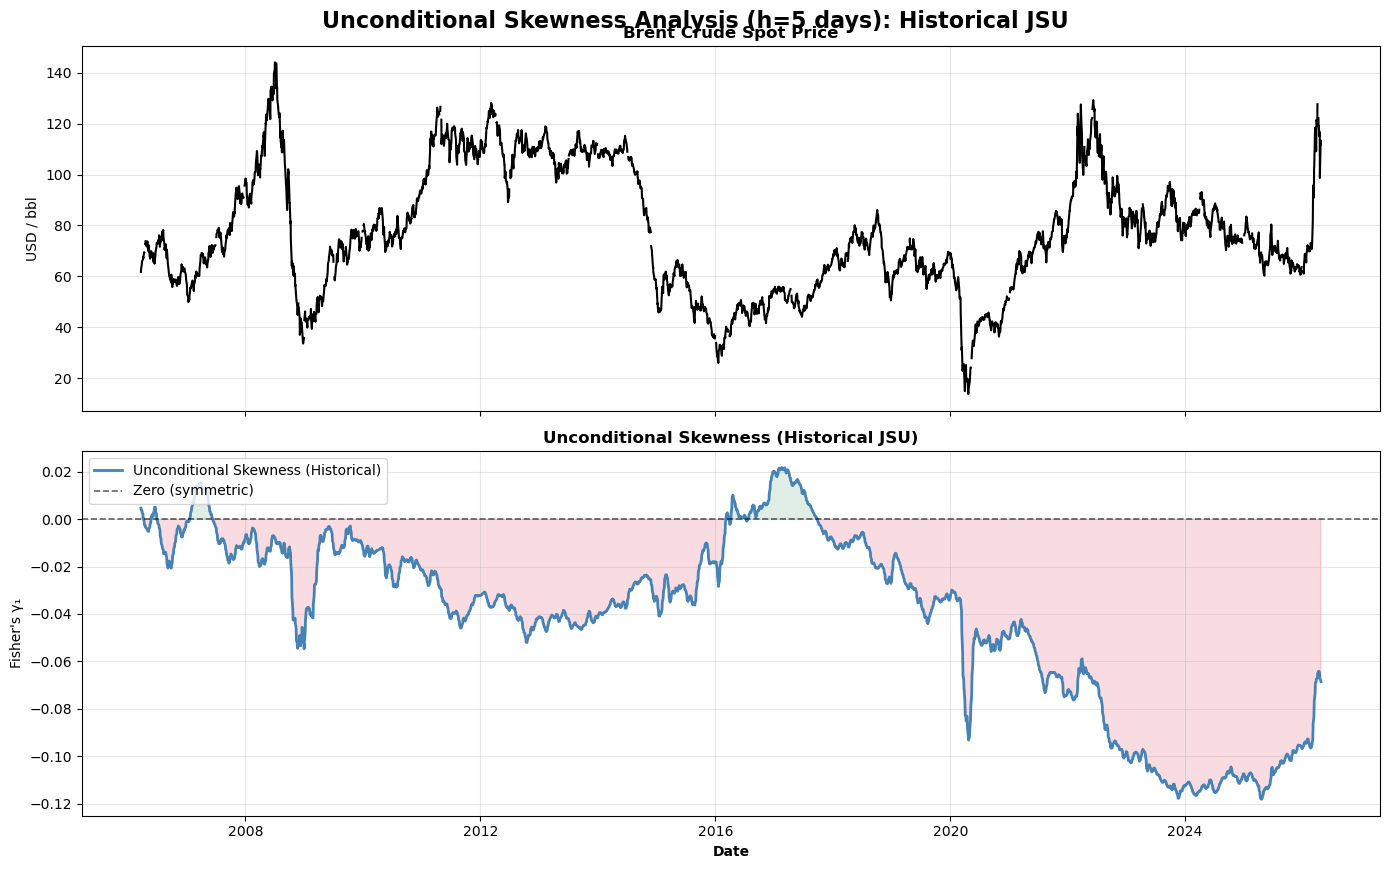

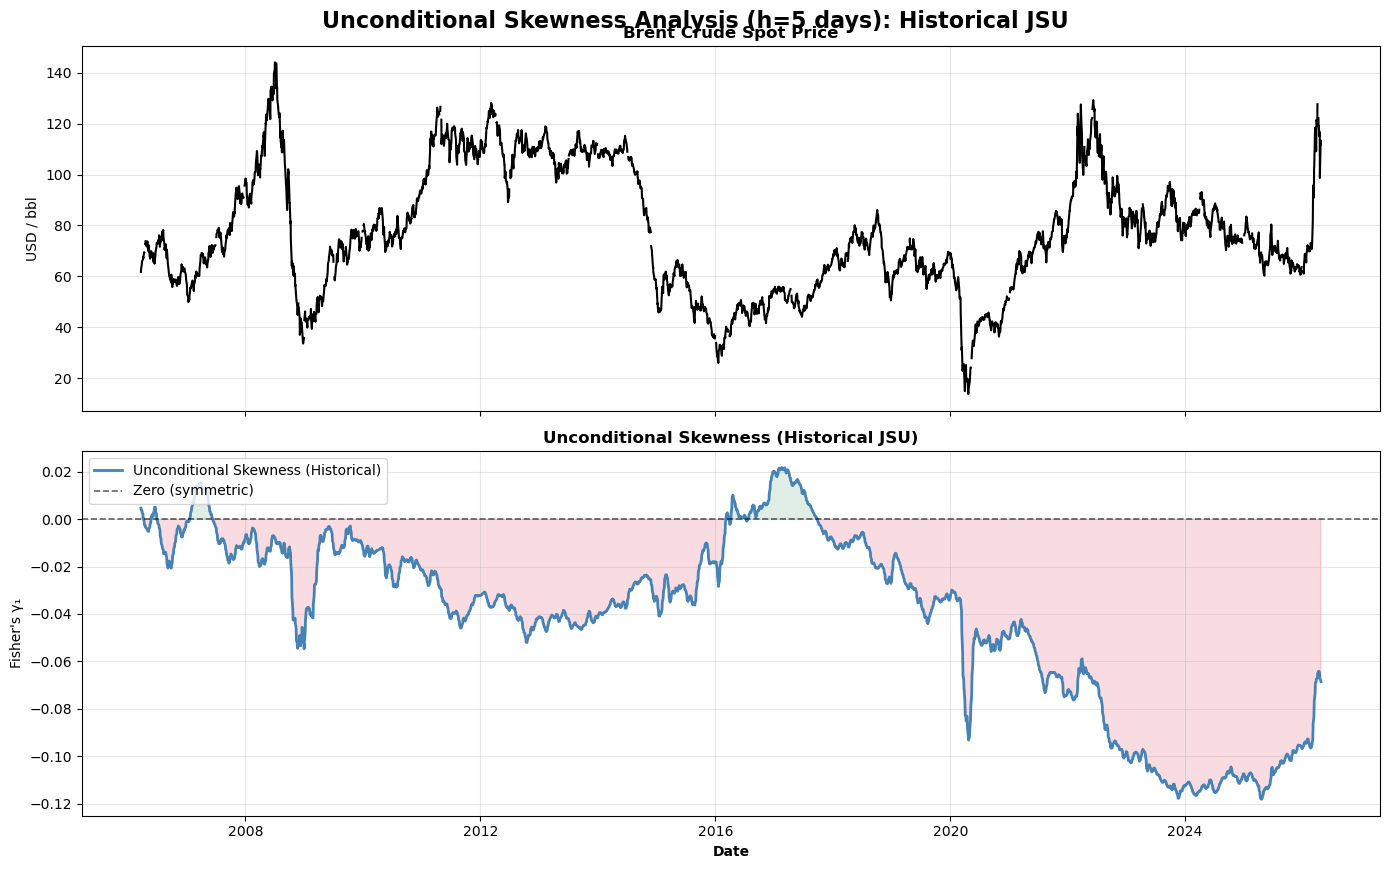

In [15]:
vm.plot_unconditional_skewness(price_series=price_series, df_skewness=df_skewness_results, h=horizon)

## 7. Value-at-Risk (VaR) — Oil-at-Risk & Growth-at-Risk

**Value-at-Risk** (VaR) is a threshold: the loss/gain that will not be exceeded
with a given confidence over a specified holding period.

Two flavours computed here:

| Flavour | Method | Time-scaling |
|---|---|---|
| **Conditional** | JSU ppf read from stored entropy params | None — QR targets $y_{t+h}$ |
| **Unconditional** | Historical Simulation (empirical quantile) | $\times\sqrt{10}$ (Basel III §OIS20) |

Both tails reported:
- **Left tail** → *Oil-at-Risk* (OaR): downside threshold (negative)
- **Right tail** → *Growth-at-Risk* (GaR): upside threshold (positive)

Defaults: 97.5% confidence, 10-day horizon, 4-year (1 008 obs) window.
The `df_entropy` argument passes the pre-computed JSU parameters
(`cond_a/b/loc/scale`) from Block 2 — no re-fitting.

In [16]:
# ── Load / compute VaR ───────────────────────────────────────────────────
import auxi.risk_metrics as rm

_p = OOS_DIR / "var.parquet"
if _p.exists():
    df_var_results = pd.read_parquet(_p)
else:
    df_var_results = rm.generate_oos_var(
        df         = data,
        y_var      = y_var,
        df_entropy = df_entropy_results_rolling,
        window     = VAR_WINDOW,
        confidence = VAR_CONFIDENCE,
        horizon    = VAR_HORIZON,
        retrain_after = retrain_after,
    )
    df_var_results.to_parquet(_p)

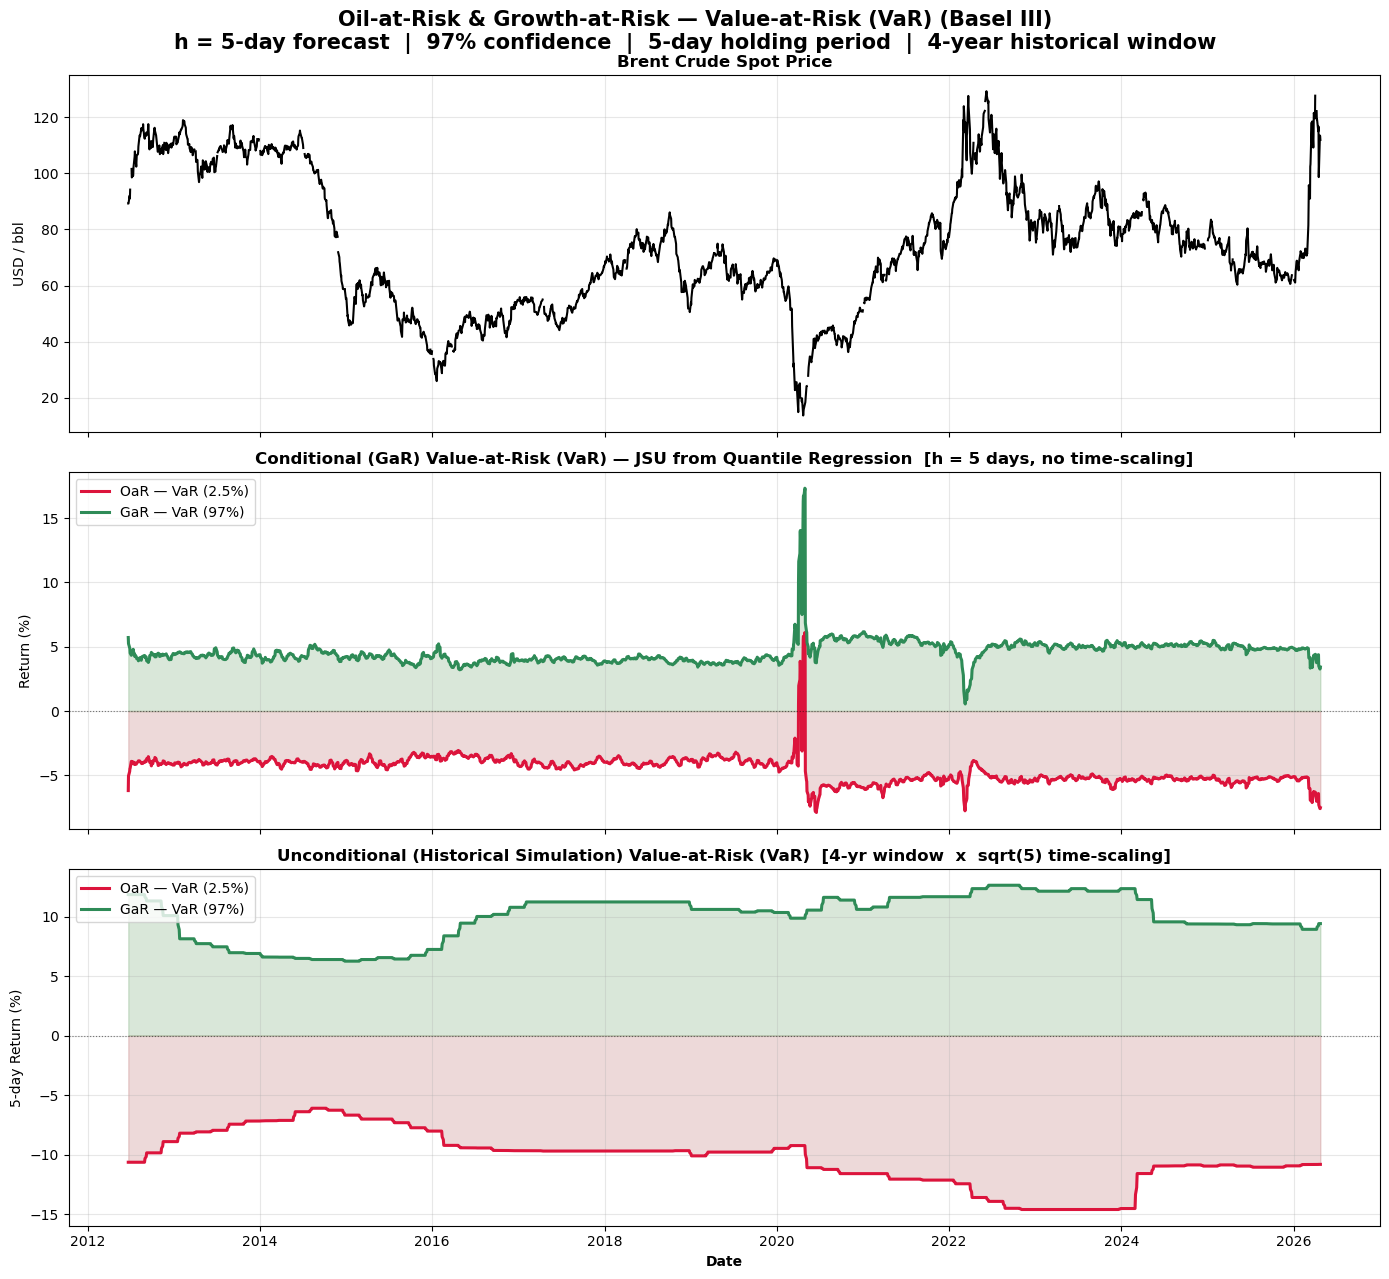

In [17]:
rm.plot_var(
    price_series = price_series,
    df_var       = df_var_results,
    h            = horizon,
    confidence   = VAR_CONFIDENCE,
    horizon      = VAR_HORIZON,
    window       = VAR_WINDOW,
)

## 8. CVaR / Expected Shortfall — Oil-at-Risk & Growth-at-Risk

**CVaR** (also called Expected Shortfall, ES) is the *expected value of losses
beyond the VaR threshold* — it measures the severity of tail events, not just
their probability. Under Basel III, CVaR/ES is the preferred coherent risk
measure for internal models (FRTB).

$$
\text{CVaR}_{\alpha} = \mathbb{E}[X \mid X \leq \text{VaR}_{\alpha}]
$$

Two flavours, fully independent of Block 7:

| Flavour | Method | Time-scaling |
|---|---|---|
| **Conditional** | Riemann integral over 5 000-pt JSU grid | None — QR targets $y_{t+h}$ |
| **Unconditional** | Empirical mean of tail observations | $\times\sqrt{10}$ (Basel III §OIS20) |

The VaR threshold is recomputed *internally* — CVaR does not call VaR functions.
Same `df_entropy` input, same two tails (OaR / GaR), same defaults.

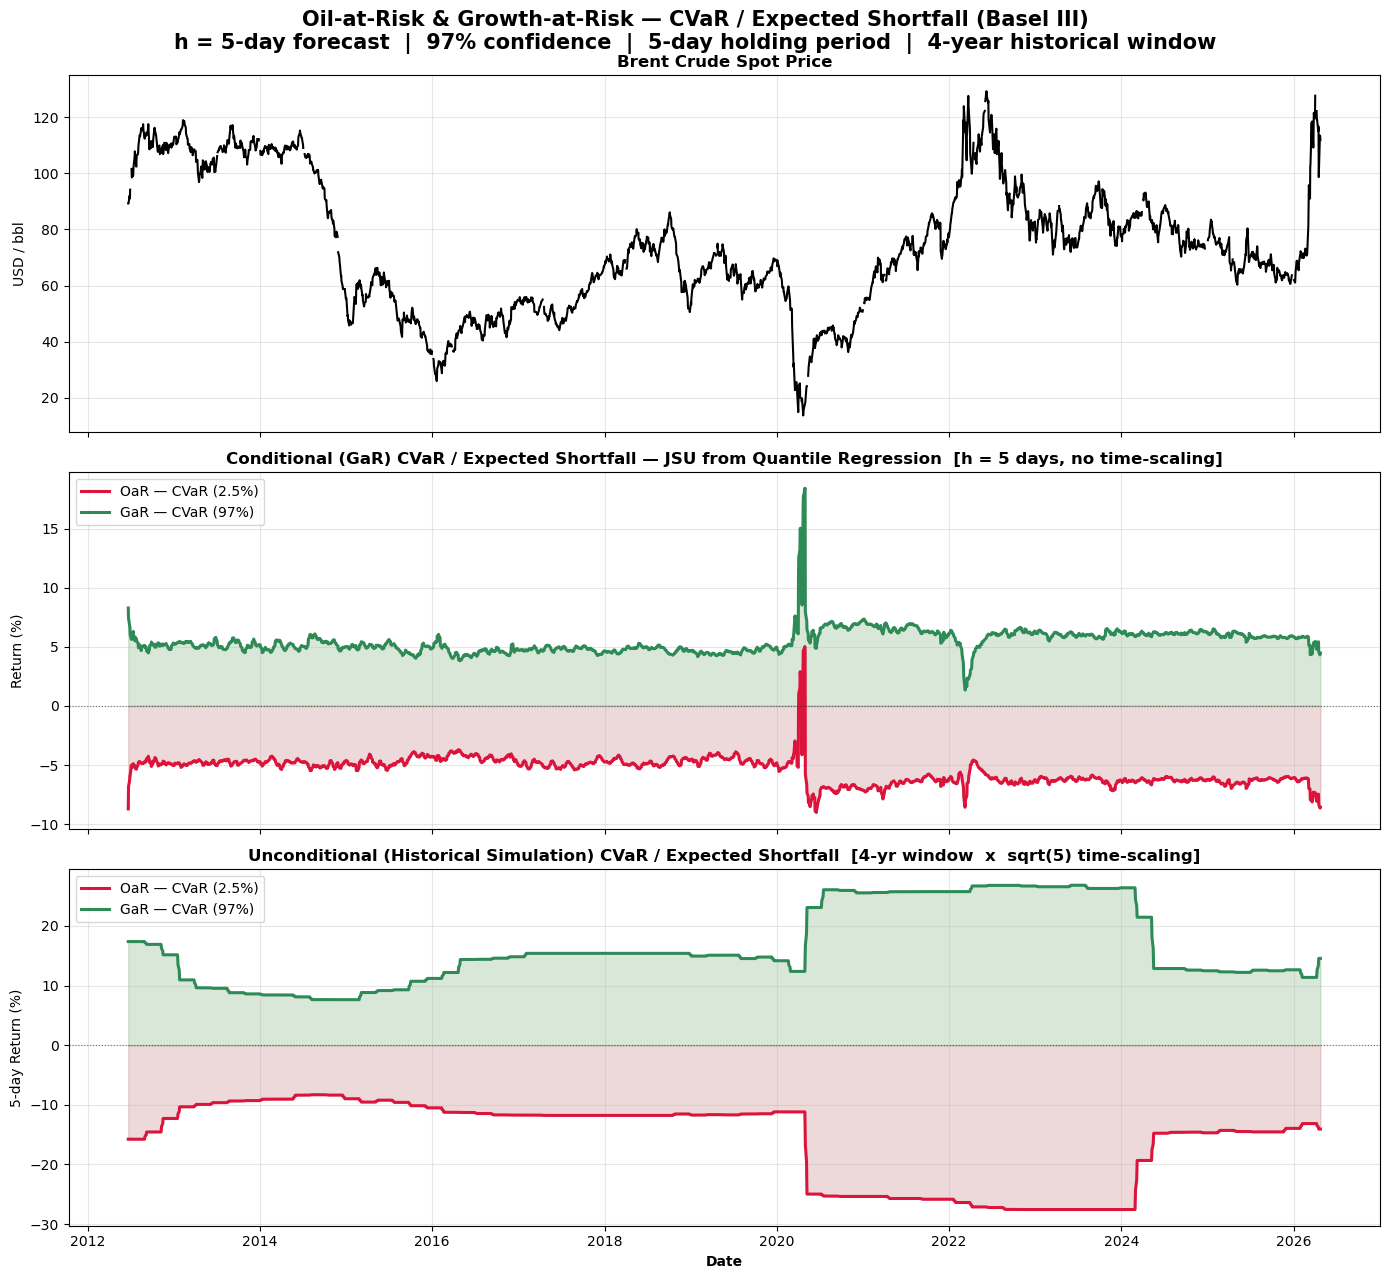

In [18]:
# ── Load / compute CVaR ──────────────────────────────────────────────────
_p = OOS_DIR / "cvar.parquet"
if _p.exists():
    df_cvar_results = pd.read_parquet(_p)
else:
    df_cvar_results = rm.generate_oos_cvar(
        df         = data,
        y_var      = y_var,
        df_entropy = df_entropy_results_rolling,
        window     = CVAR_WINDOW,
        confidence = CVAR_CONFIDENCE,
        horizon    = CVAR_HORIZON,
        retrain_after = retrain_after,
    )
    df_cvar_results.to_parquet(_p)

rm.plot_cvar(
    price_series = price_series,
    df_cvar      = df_cvar_results,
    h            = horizon,
    confidence   = CVAR_CONFIDENCE,
    horizon      = CVAR_HORIZON,
    window       = CVAR_WINDOW,
)

## 9. Early Warning System — Do Entropy Measures Anticipate Oil Returns?

The vulnerability metrics computed above measure *how far* the conditional density departs
from a baseline at each date. A natural follow-up question is whether these measures
**lead** oil-price movements — i.e., whether a spike in tail entropy today foreshadows
large returns tomorrow.

We apply three diagnostics adapted from the composite-indicator literature
(Bujosa, García-Ferrer & de Juan, 2013):

1. **Cross-Correlation Function (CCF)** — correlation between the indicator and the target
   at lags $-24 \dots +24$. A peak at $h^* > 0$ means the indicator leads the target by
   $h^*$ periods. Bartlett's 95 % confidence band ($\pm 1.96 / \sqrt{N}$) identifies
   significant lead/lag relationships.
2. **Granger Causality Test** — an F-test comparing a restricted AR model of the target
   against an unrestricted model that adds lagged indicator values. Lag order selected by
   AIC. Rejection means the indicator carries predictive information beyond the target's
   own history.
3. **Anticipation Test** — the CCF and Granger test combined into a single summary per
   indicator, reported in the EWS battery table.

The three indicators tested are the **Full**, **Left-tail**, and **Right-tail** KL
divergences from the entropy results. Returns are already stationary; only the
entropy series are first-differenced.

In [33]:
import auxi.diagnostics as diags

# ── Choose which entropy file to use for the EWS tests ───────────────────
# Change the filename below to switch between expanding / rolling results.
EWS_ENTROPY_FILE = OOS_DIR / "entropy_roll.parquet"   # or "entropy_exp.parquet"

df_entropy_ews = pd.read_parquet(EWS_ENTROPY_FILE)
print(f"Loaded: {EWS_ENTROPY_FILE.name}  ({len(df_entropy_ews)} obs)")

Loaded: entropy_roll.parquet  (2168 obs)


In [44]:
# ── Prepare series ───────────────────────────────────────────────────────
# Target: Brent returns (already stationary — no differencing)
common_idx = data[y_var].dropna().index.intersection(df_entropy_ews.index)
target = data[y_var].reindex(common_idx)

# Indicators: entropy measures, first-differenced for stationarity
indicators_diff = {
    "Full Entropy":  df_entropy_ews["Full_Entropy"].reindex(common_idx).dropna(),
    "Left Entropy":  df_entropy_ews["Left_Entropy"].reindex(common_idx).dropna(),
    "Right Entropy": df_entropy_ews["Right_Entropy"].reindex(common_idx).dropna(),
}

# Re-align target to the differenced index (drops the first obs lost to diff)
final_idx = indicators_diff["Full Entropy"].index
target = target.reindex(final_idx)

print(f"EWS sample: {len(target)} obs, {target.index[0].date()} → {target.index[-1].date()}")

EWS sample: 2168 obs, 2012-06-21 → 2026-04-24


In [45]:
# ── EWS Battery: summary table ───────────────────────────────────────────
battery_df = diags.compute_ews_battery(
    indicators_diff, target,
    max_lag_ccf=24, max_lag_granger=100, criterion="aic",
)
battery_df

,Indicator,h_star,r_at_hstar,CCF_Significant,Granger_F,Granger_p,Granger_Lag,Granger_Stars
0,Full Entropy,7,0.2910,True,21.1928,0.0,34,***
1,Left Entropy,16,-0.0863,True,5.1144,0.0,17,***
2,Right Entropy,7,0.3114,True,22.1328,0.0,32,***


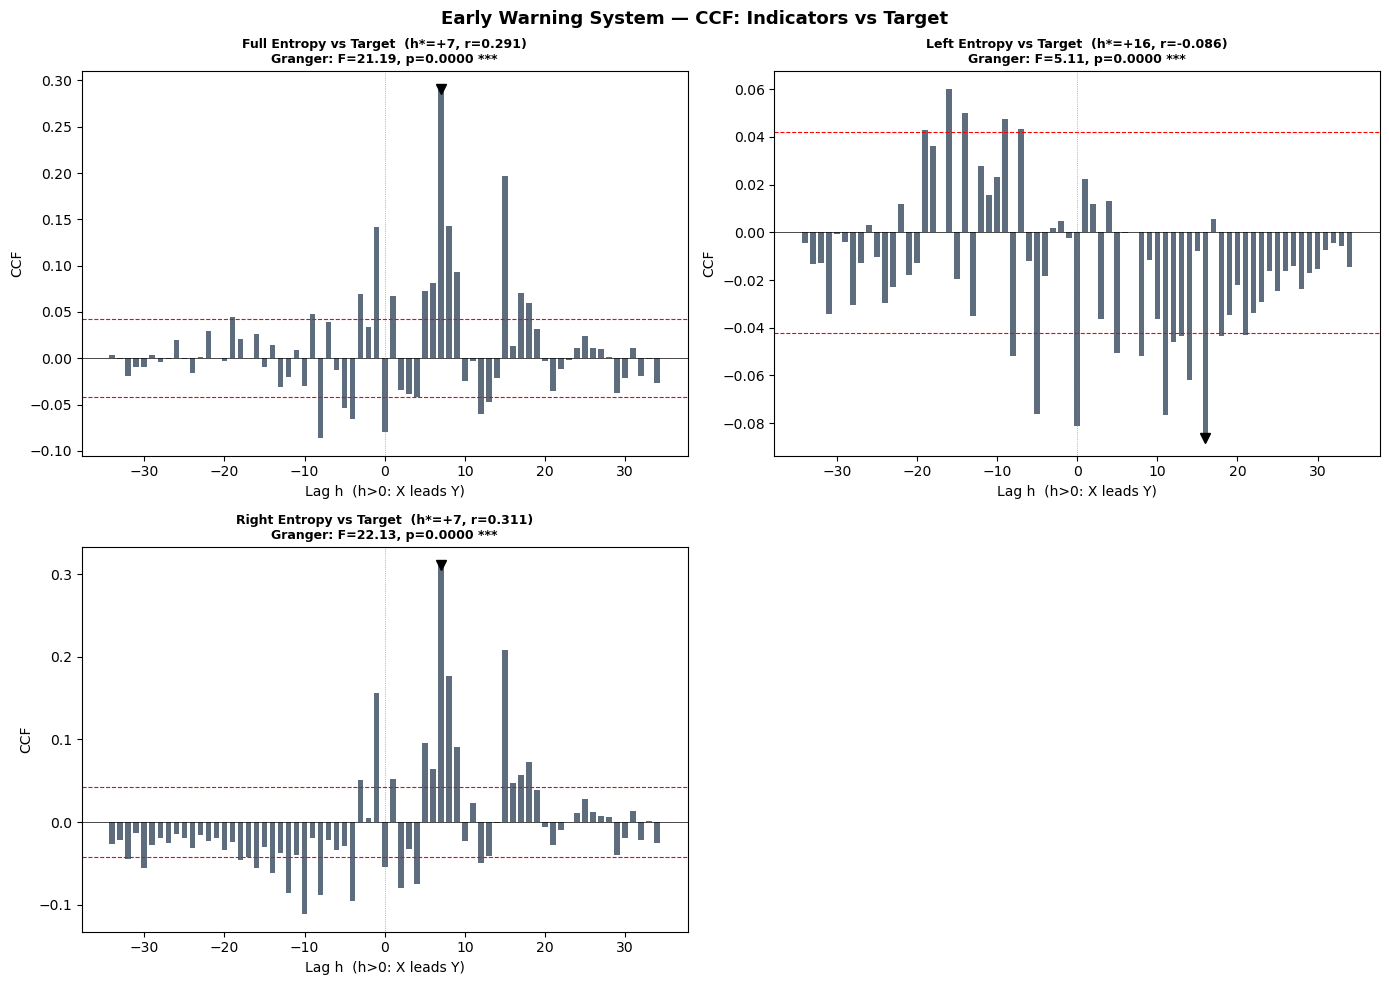

In [46]:
# ── EWS Battery: CCF panels ──────────────────────────────────────────────
fig_battery = diags.plot_ews_battery(
    battery_df, indicators_diff, target, max_lag_ccf=34,
)
plt.show()

In [23]:
# ── Internal Coherence: pairwise CCF among the three entropy measures ────
coherence_df = diags.compute_coherence_test(indicators_diff, max_lag=24)
coherence_df

,Series_X,Series_Y,h_star,r_at_hstar,Significant
0,Full Entropy,Left Entropy,0,0.7476,True
1,Full Entropy,Right Entropy,0,0.6311,True
2,Left Entropy,Right Entropy,0,-0.0358,False


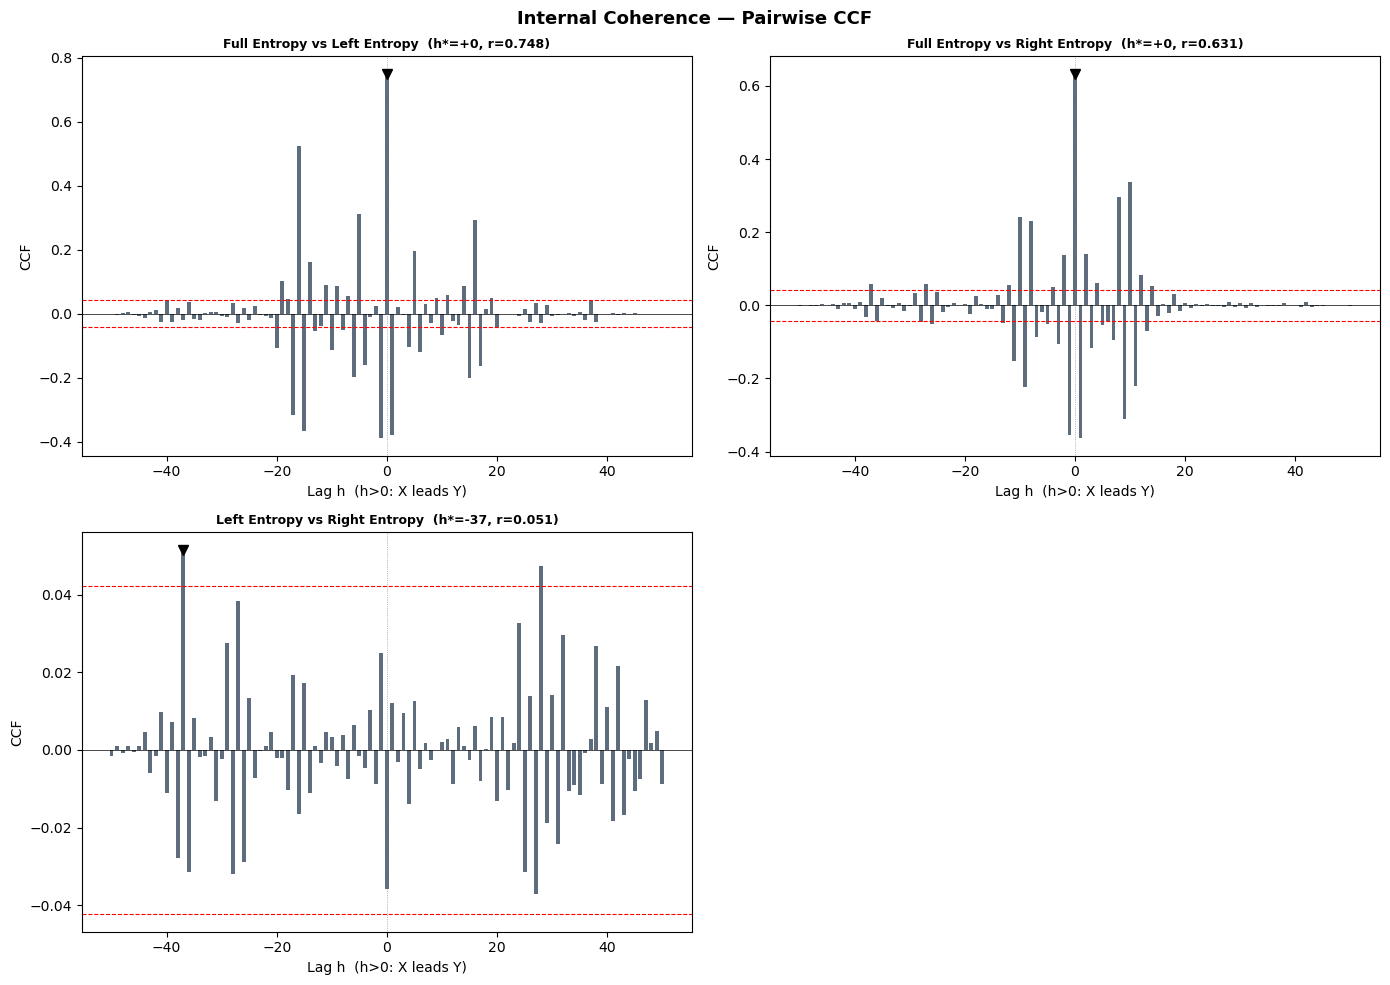

In [24]:
# ── Coherence dashboard: pairwise CCF plots ─────────────────────────────
fig_coherence = diags.plot_coherence_dashboard(coherence_df, indicators_diff, max_lag=50)
plt.show()